<a href="https://colab.research.google.com/github/lucassaeztoledo/ProyectosAlura/blob/master/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [2]:
import pandas as pd
import requests

# 1. Definir la URL del archivo JSON en formato raw
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    # 2. Cargar los datos directamente desde la "API" (URL) utilizando requests
    response = requests.get(url)
    response.raise_for_status()  # Verifica que la descarga fue exitosa

    # 3. Convertir el contenido JSON a una lista/diccionario de Python
    data = response.json()

    # 4. Convertir los datos a un DataFrame de Pandas
    df = pd.DataFrame(data)

    # Mostrar las primeras filas para verificar
    print("Datos cargados exitosamente:")
    print(df.head())

except requests.exceptions.RequestException as e:
    print(f"Error al cargar los datos: {e}")

Datos cargados exitosamente:
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber opt

### **Estandarización y Transformación de Datos**

In [9]:
# Mapear 'Yes' a 1 y 'No' a 0 para columnas binarias, preservando NA
binary_map = {'Yes': 1, 'No': 0}

# Columnas a las que aplicar el mapeo binario directamente
columns_to_map_binary = [
    'Partner',
    'Dependents',
    'PaperlessBilling',
    'Churn'
]

for col in columns_to_map_binary:
    if col in df.columns:
        # Capturar la máscara de valores NA originales antes de cualquier conversión a string
        original_na_mask = df[col].isna()
        # Mapear los valores a binarios, coercing cualquier otro valor a NaN
        mapped_series = df[col].astype(str).map(binary_map)
        # Convertir a numérico, coercing errores (ej. 'nan' de los NA originales no mapeados)
        df[col] = pd.to_numeric(mapped_series, errors='coerce')
        # Restaurar los valores NA originales
        df.loc[original_na_mask, col] = pd.NA

# Convertir SeniorCitizen a tipo numérico (ya está en 0 y 1, pero asegurar tipo)
if 'SeniorCitizen' in df.columns:
    df['SeniorCitizen'] = pd.to_numeric(df['SeniorCitizen'], errors='coerce')

# Mapear otras columnas que tienen 'No internet service' o 'No phone service'
# Estas se consideran como 'No' en este contexto (0)
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in service_columns:
    if col in df.columns:
        df[col] = df[col].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})
        # Asegurarse de que el tipo sea numérico
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('\nDataFrame después de la conversión a valores binarios:')
display(df.head())
display(df.info())


DataFrame después de la conversión a valores binarios:


/tmp/ipykernel_5130/3549061945.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1.0,1.0,9,1,0,DSL,...,1,0,1,1,0,One year,1.0,Mailed check,593.30,19.776667
1,0003-MKNFE,0.0,Male,0,0.0,0.0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0.0,Mailed check,542.40,18.080000
2,0004-TLHLJ,1.0,Male,0,0.0,0.0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1.0,Electronic check,280.85,9.361667
3,0011-IGKFF,1.0,Male,1,1.0,0.0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1.0,Electronic check,1237.85,41.261667
4,0013-EXCHZ,1.0,Female,1,1.0,0.0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1.0,Mailed check,267.40,8.913333


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   float64
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   float64
 5   Dependents        7267 non-null   float64
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   int64  
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   int64  
 11  OnlineBackup      7267 non-null   int64  
 12  DeviceProtection  7267 non-null   int64  
 13  TechSupport       7267 non-null   int64  
 14  StreamingTV       7267 non-null   int64  
 15  StreamingMovies   7267 non-null   int64  
 16  Contract          7267 non-null   object 


None

Ahora, vamos a renombrar algunas columnas para mayor claridad y eliminar la columna `customerID`.

In [10]:
# Renombrar columnas para mayor claridad
df.rename(columns={
    'gender': 'Genero',
    'SeniorCitizen': 'Ciudadano_Senior',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Antiguedad_Meses',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Copia_Seguridad_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Television_Streaming',
    'StreamingMovies': 'Peliculas_Streaming',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'Charges': 'Cargos_Mensuales_Total'
}, inplace=True)

# Eliminar la columna 'customerID' ya que no es relevante para el análisis predictivo
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

print('\nDataFrame después de renombrar columnas y eliminar customerID:')
display(df.head())
display(df.info())


DataFrame después de renombrar columnas y eliminar customerID:


,Churn,Genero,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,Television_Streaming,Peliculas_Streaming,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales_Total,Cuentas_Diarias
0,0.0,Female,0,1.0,1.0,9,1,0,DSL,0,1,0,1,1,0,One year,1.0,Mailed check,593.30,19.776667
1,0.0,Male,0,0.0,0.0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0.0,Mailed check,542.40,18.080000
2,1.0,Male,0,0.0,0.0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1.0,Electronic check,280.85,9.361667
3,1.0,Male,1,1.0,0.0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1.0,Electronic check,1237.85,41.261667
4,1.0,Female,1,1.0,0.0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1.0,Mailed check,267.40,8.913333


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    7043 non-null   float64
 1   Genero                   7267 non-null   object 
 2   Ciudadano_Senior         7267 non-null   int64  
 3   Pareja                   7267 non-null   float64
 4   Dependientes             7267 non-null   float64
 5   Antiguedad_Meses         7267 non-null   int64  
 6   Servicio_Telefonico      7267 non-null   int64  
 7   Multiples_Lineas         7267 non-null   int64  
 8   Servicio_Internet        7267 non-null   object 
 9   Seguridad_Online         7267 non-null   int64  
 10  Copia_Seguridad_Online   7267 non-null   int64  
 11  Proteccion_Dispositivo   7267 non-null   int64  
 12  Soporte_Tecnico          7267 non-null   int64  
 13  Television_Streaming     7267 non-null   int64  
 14  Peliculas_Streaming     

None

Con esto, hemos completado la estandarización y transformación de los datos, convirtiendo valores textuales a binarios y renombrando las columnas para una mayor claridad. El DataFrame está ahora en un formato más adecuado para las etapas de análisis exploratorio y modelado.

### **Creación de 'Cuentas_Diarias'**

In [7]:
# Crear la columna 'Cuentas_Diarias' dividiendo los 'Charges' por 30 (días aproximados en un mes)
df['Cuentas_Diarias'] = df['Charges'] / 30

print('DataFrame con la nueva columna Cuentas_Diarias:')
display(df.head())

DataFrame con la nueva columna Cuentas_Diarias:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,593.30,19.776667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,542.40,18.080000
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,280.85,9.361667
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,1237.85,41.261667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,267.40,8.913333


In [8]:
print('\nEstadísticas descriptivas de Cuentas_Diarias:')
display(df['Cuentas_Diarias'].describe())


Estadísticas descriptivas de Cuentas_Diarias:


,Cuentas_Diarias
count,7267.000000
mean,75.976253
std,75.572632
min,0.626667
25%,13.380000
50%,46.366667
75%,125.950833
max,289.493333


La columna `Cuentas_Diarias` ha sido creada exitosamente, proporcionando una estimación del costo diario para cada cliente a partir de su facturación total mensual. Esto nos permite un análisis más granular del gasto de los clientes. Ahora, continuaremos con la estandarización y transformación de datos.

### **Verificación de la calidad de los datos**

In [5]:
print('Valores ausentes por columna (antes de limpieza específica):')
display(df.isnull().sum())

Valores ausentes por columna (antes de limpieza específica):


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


La columna `Churn` contiene el valor ' ' (espacio en blanco) que debe ser tratado como un valor ausente (`pd.NA`). La columna `Charges` es de tipo `object` y aún contiene diccionarios anidados con 'Monthly' y 'Total', de donde se extraerá el 'Total'.

In [6]:
# 1. Manejar el valor ' ' en la columna 'Churn'
if 'Churn' in df.columns:
    df['Churn'] = df['Churn'].astype(str).str.strip().replace('', pd.NA)

# 2. Procesar la columna 'Charges'
# Extraer el valor 'Total' de la columna 'Charges' que contiene diccionarios
df['Charges'] = df['Charges'].apply(lambda x: x.get('Total') if isinstance(x, dict) else x)

# Convertir la columna 'Charges' a tipo numérico, reemplazando espacios en blanco o errores por NaN
df['Charges'] = pd.to_numeric(df['Charges'], errors='coerce')

# Rellenar los valores NaN con la mediana de la columna o con 0 si la mediana es NaN
median_val_charges = df['Charges'].median()
if pd.isna(median_val_charges):
    df['Charges'] = df['Charges'].fillna(0)
    print("\nAdvertencia: La mediana de 'Charges' es NaN. Los valores no numéricos se han rellenado con 0.")
else:
    df['Charges'] = df['Charges'].fillna(median_val_charges)
    print(f"\nValores NaN en 'Charges' rellenados con la mediana: {median_val_charges}")


# 3. Preparar columnas 'object' para la comprobación de duplicados y valores únicos
# Convertir todas las columnas de tipo 'object' a 'string' para asegurar la capacidad de hash
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)


print('\nValores ausentes por columna (después de limpieza específica):')
display(df.isnull().sum())

print('\nNúmero de filas duplicadas:')
display(df.duplicated().sum())

print('\nVerificando valores únicos en columnas categóricas después de la limpieza:')
for column in df.select_dtypes(include='object').columns:
    if column not in ['customerID']:
        print(f"\nColumna '{column}':")
        display(df[column].value_counts(dropna=False))


Valores NaN en 'Charges' rellenados con la mediana: 1391.0

Valores ausentes por columna (después de limpieza específica):


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0



Número de filas duplicadas:


np.int64(0)


Verificando valores únicos en columnas categóricas después de la limpieza:

Columna 'Churn':


...

,count
Contract,
Month-to-month,4005
Two year,1743
One year,1519



Columna 'PaperlessBilling':


,count
PaperlessBilling,
Yes,4311
No,2956



Columna 'PaymentMethod':


,count
PaymentMethod,
Electronic check,2445
Mailed check,1665
Bank transfer (automatic),1589
Credit card (automatic),1568


Con esto, hemos completado la verificación y limpieza de las inconsistencias clave en el DataFrame. Las columnas `Churn` y `Charges` han sido procesadas correctamente, no hay filas duplicadas y hemos inspeccionado los valores únicos de las columnas categóricas. Los datos están ahora listos para la siguiente fase de estandarización y transformación.

#🔧 Transformación

In [4]:
# Desanidar las columnas 'customer', 'phone', 'internet' y 'account'
# Expandir las columnas anidadas en nuevas columnas del DataFrame
expanded_customer = df['customer'].apply(pd.Series)
expanded_phone = df['phone'].apply(pd.Series)
expanded_internet = df['internet'].apply(pd.Series)
expanded_account = df['account'].apply(pd.Series)

# Unir las nuevas columnas al DataFrame original y eliminar las columnas anidadas
df = pd.concat([
    df.drop(columns=['customer', 'phone', 'internet', 'account']),
    expanded_customer,
    expanded_phone,
    expanded_internet,
    expanded_account
], axis=1)

print('\nDataFrame después de desanidar las columnas:')
df.info()
display(df.head())


DataFrame después de desanidar las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7267 non-null   object
 1   Churn             7267 non-null   object
 2   gender            7267 non-null   object
 3   SeniorCitizen     7267 non-null   int64 
 4   Partner           7267 non-null   object
 5   Dependents        7267 non-null   object
 6   tenure            7267 non-null   int64 
 7   PhoneService      7267 non-null   object
 8   MultipleLines     7267 non-null   object
 9   InternetService   7267 non-null   object
 10  OnlineSecurity    7267 non-null   object
 11  OnlineBackup      7267 non-null   object
 12  DeviceProtection  7267 non-null   object
 13  TechSupport       7267 non-null   object
 14  StreamingTV       7267 non-null   object
 15  StreamingMovies   7267 non-null   object
 16  Contract      

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"


In [3]:
print('Información general del DataFrame:')
df.info()

print('\nPrimeras 5 filas del DataFrame:')
display(df.head())

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

Primeras 5 filas del DataFrame:


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


Como se puede observar en la información general y las primeras filas del DataFrame, las columnas 'customer', 'phone', 'internet' y 'account' contienen diccionarios anidados. Será necesario desanidar estas columnas para acceder a toda la información y poder realizar un análisis más profundo y la correcta identificación de las variables relevantes para el análisis de evasión. En particular, la columna 'Charges' también es parte de la información anidada dentro de 'account', y deberá ser extraída y convertida correctamente.

#📊 Carga y análisis

### **Análisis Descriptivo de los Datos**

In [12]:
print('\nEstadísticas descriptivas de las columnas categóricas:')
for column in df.select_dtypes(include='object').columns:
    print(f"\nColumna '{column}':")
    display(df[column].value_counts(dropna=False))


Estadísticas descriptivas de las columnas categóricas:

Columna 'Genero':


,count
Genero,
Male,3675
Female,3592



Columna 'Servicio_Internet':


,count
Servicio_Internet,
Fiber optic,3198
DSL,2488
No,1581



Columna 'Tipo_Contrato':


,count
Tipo_Contrato,
Month-to-month,4005
Two year,1743
One year,1519



Columna 'Metodo_Pago':


,count
Metodo_Pago,
Electronic check,2445
Mailed check,1665
Bank transfer (automatic),1589
Credit card (automatic),1568


Este análisis descriptivo nos proporciona una primera visión de las características de nuestros clientes. Hemos obtenido métricas clave para las columnas numéricas y la distribución de valores para las categóricas, lo que nos permite entender mejor la estructura y el comportamiento de los datos.

In [11]:
print('Información general del DataFrame:')
df.info()

print('\nEstadísticas descriptivas de las columnas numéricas:')
display(df.describe())

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    7043 non-null   float64
 1   Genero                   7267 non-null   object 
 2   Ciudadano_Senior         7267 non-null   int64  
 3   Pareja                   7267 non-null   float64
 4   Dependientes             7267 non-null   float64
 5   Antiguedad_Meses         7267 non-null   int64  
 6   Servicio_Telefonico      7267 non-null   int64  
 7   Multiples_Lineas         7267 non-null   int64  
 8   Servicio_Internet        7267 non-null   object 
 9   Seguridad_Online         7267 non-null   int64  
 10  Copia_Seguridad_Online   7267 non-null   int64  
 11  Proteccion_Dispositivo   7267 non-null   int64  
 12  Soporte_Tecnico          7267 non-null   int64  
 13  Television_Streaming     7267 non-null   in

,Churn,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,Television_Streaming,Peliculas_Streaming,Facturacion_Electronica,Cargos_Mensuales_Total,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,2279.287581,75.976253
std,0.441561,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,2267.178963,75.572632
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.800000,0.626667
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,401.400000,13.380000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1391.000000,46.366667
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3778.525000,125.950833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8684.800000,289.493333


### **Análisis de la distribución de la variable 'Churn'**

Para comprender la proporción de clientes que se han dado de baja (`Yes`) y los que han permanecido (`No`), visualizaremos la distribución de la columna 'Churn' mediante un gráfico de barras.

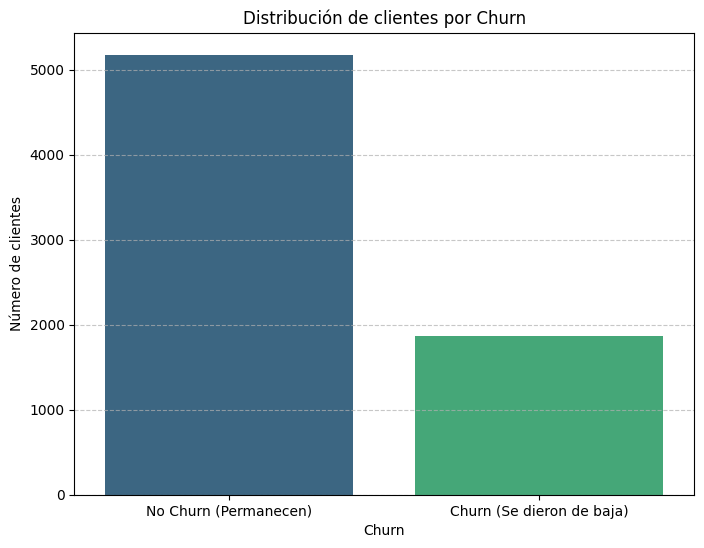

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Distribución de clientes por Churn')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.xticks(ticks=[0, 1], labels=['No Churn (Permanecen)', 'Churn (Se dieron de baja)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Este gráfico nos permite observar de forma clara la proporción de clientes que se dieron de baja (Churn) frente a los que permanecieron. Es un primer paso fundamental para entender el problema de la evasión.

### **Análisis de Churn por variables categóricas**

Analizaremos la distribución de la evasión (`Churn`) para diferentes variables categóricas, como `Genero`, `Servicio_Internet`, `Tipo_Contrato` y `Metodo_Pago`. Esto nos permitirá identificar qué perfiles de clientes muestran una mayor o menor tendencia a darse de baja.

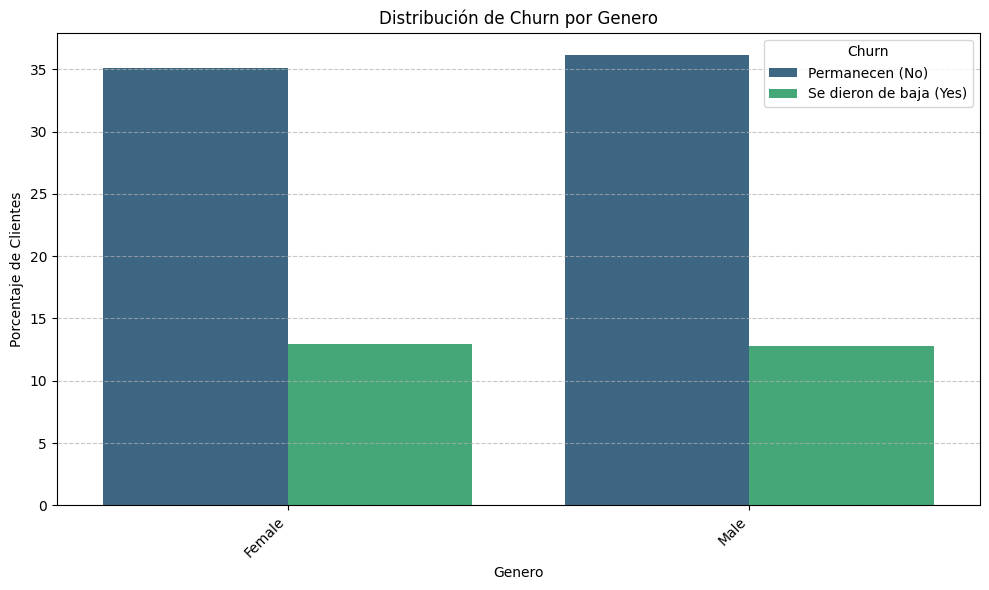

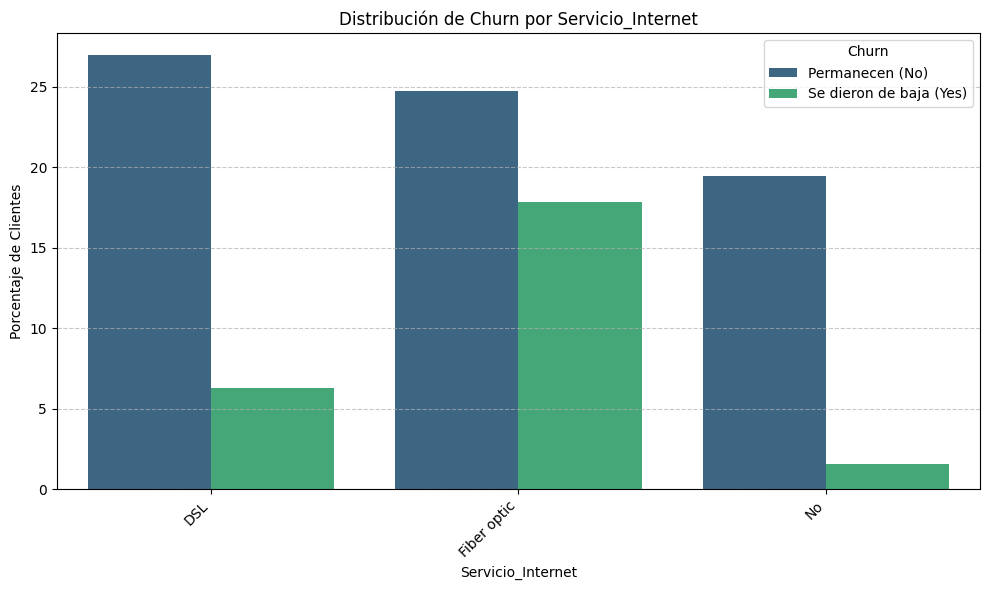

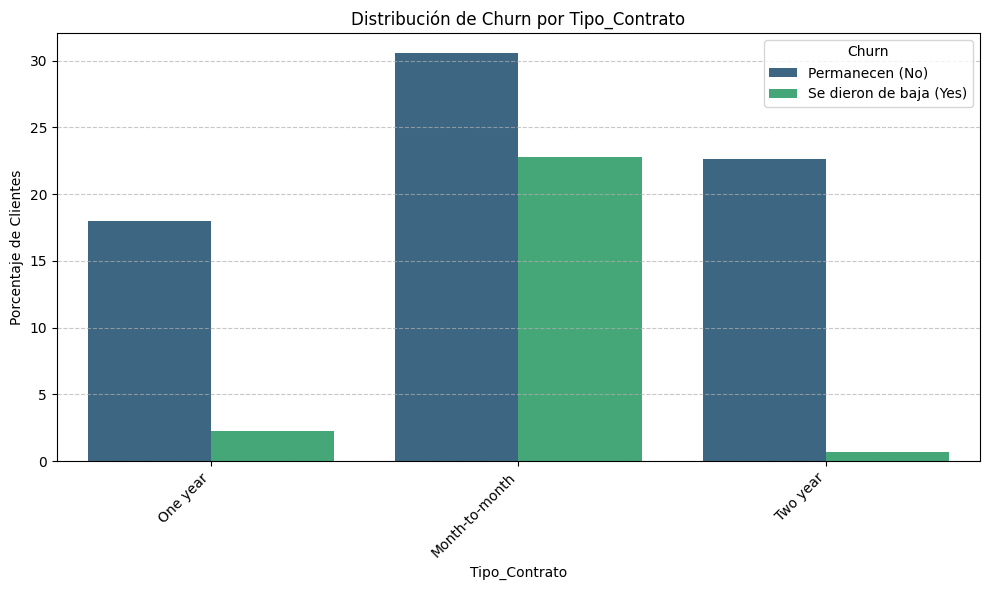

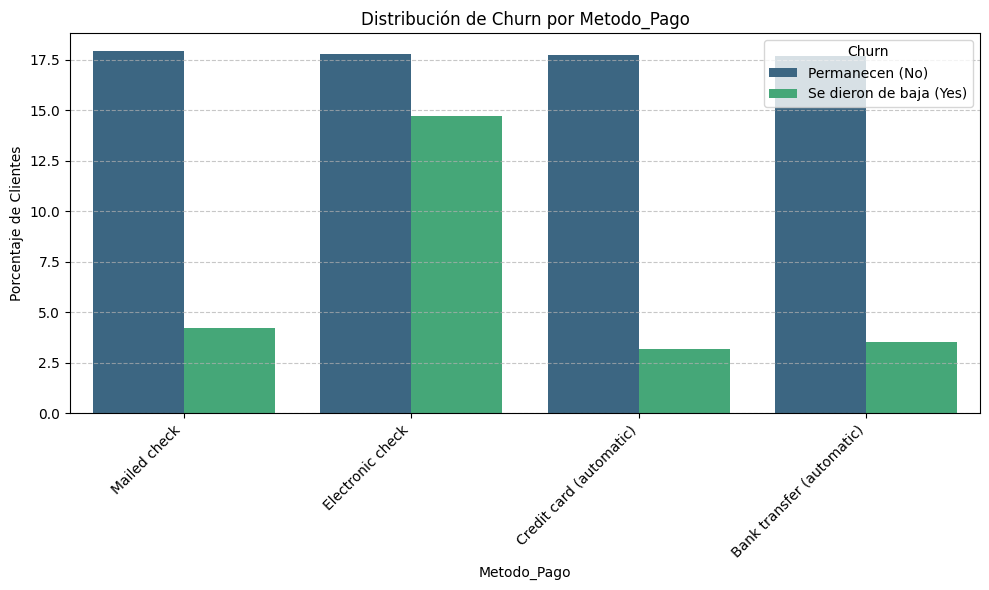

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'Genero',
    'Servicio_Internet',
    'Tipo_Contrato',
    'Metodo_Pago'
]

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='Churn', data=df, palette='viridis', stat='percent') # common_norm=False eliminado
    plt.title(f'Distribución de Churn por {col}')
    plt.xlabel(col)
    plt.ylabel('Porcentaje de Clientes')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Churn', labels=['Permanecen (No)', 'Se dieron de baja (Yes)'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Estos gráficos nos proporcionan una visión detallada de cómo la tasa de `Churn` varía entre diferentes categorías. Podemos observar qué grupos de clientes son más propensos a la evasión, lo cual es fundamental para el diseño de estrategias de retención.

### **Análisis de Churn por Variables Numéricas**

Exploraremos cómo las variables numéricas, como `Cargos_Mensuales_Total` y `Antiguedad_Meses`, se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron. Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la evasión.

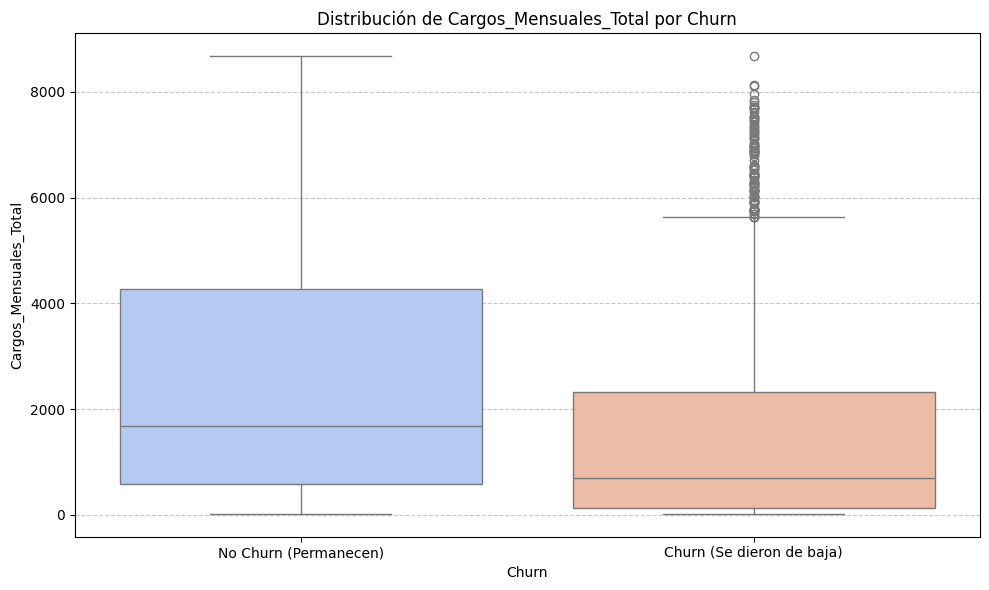

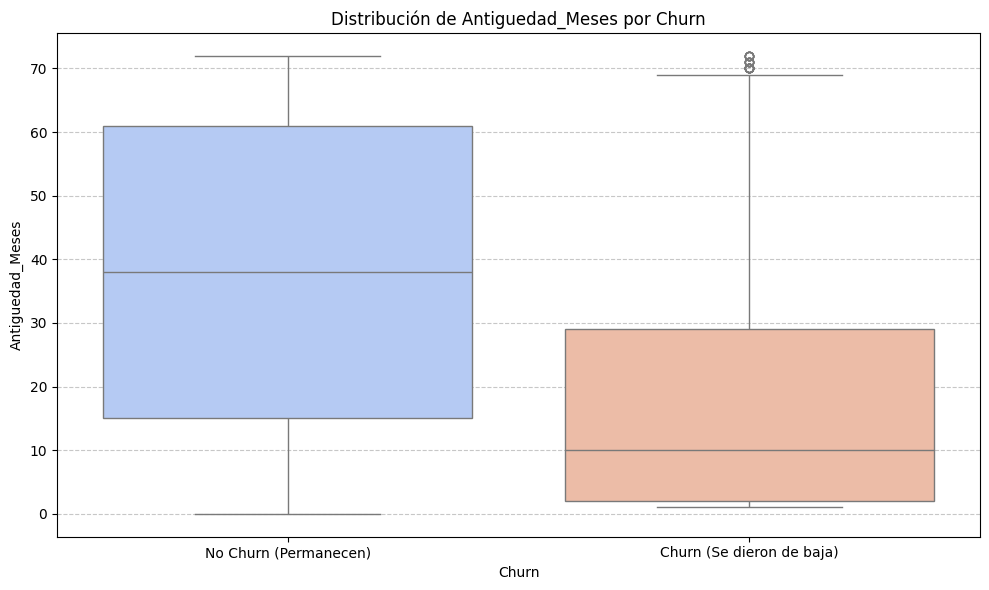

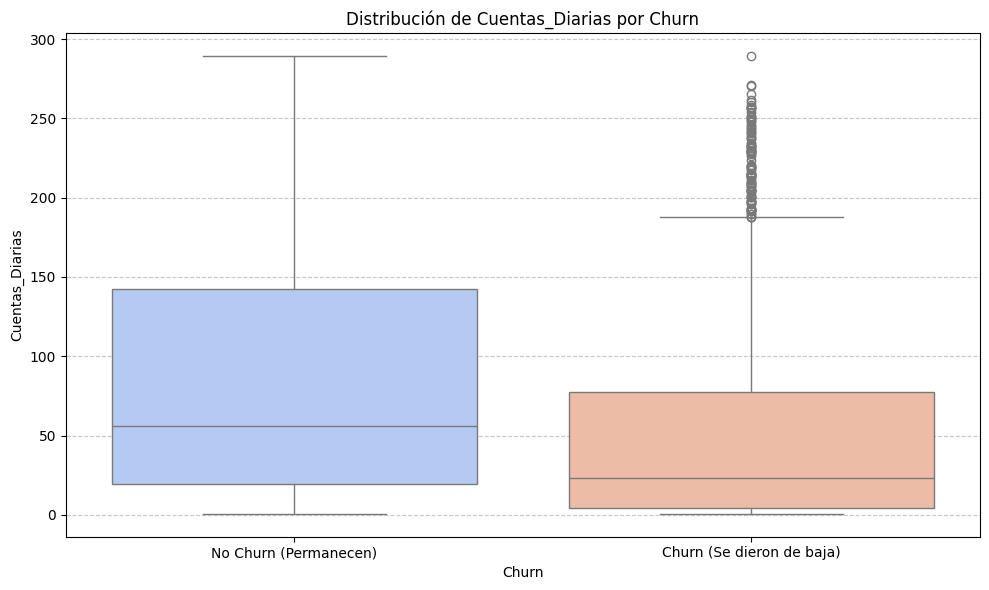

In [19]:
numerical_cols = [
    'Cargos_Mensuales_Total',
    'Antiguedad_Meses',
    'Cuentas_Diarias' # Incluir la nueva columna de cuentas diarias
]

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Churn', y=col, data=df, palette='coolwarm', hue='Churn', legend=False)
    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.xticks(ticks=[0, 1], labels=['No Churn (Permanecen)', 'Churn (Se dieron de baja)'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Estos gráficos de caja y bigotes nos permiten comparar las distribuciones de `Cargos_Mensuales_Total`, `Antiguedad_Meses` y `Cuentas_Diarias` entre los clientes que se dieron de baja y los que permanecieron. Podemos observar diferencias en las medianas, rangos intercuartílicos y presencia de valores atípicos que pueden ser indicadores importantes de la propensión a la evasión.

#📄Informe final

## Introducción

Este informe busca analizar el problema de la evasión de clientes (Churn) en el sector de las telecomunicaciones, específicamente para la empresa TelecomX. La evasión de clientes representa un desafío significativo para las empresas de telecomunicaciones, ya que implica la pérdida de ingresos, el aumento de costos asociados a la adquisición de nuevos clientes y un impacto negativo en la base de usuarios a largo plazo.

Mediante un análisis exhaustivo de los datos de clientes, se busca identificar los factores clave que contribuyen a que los clientes decidan darse de baja de los servicios de TelecomX. Comprender estos factores permitirá desarrollar estrategias de retención efectivas, mejorar la satisfacción del cliente y optimizar las operaciones comerciales. Este análisis proporcionará información valiosa sobre el comportamiento de los clientes y las variables que influyen en su decisión de permanencia, sentando las bases para futuras acciones orientadas a minimizar el Churn.

## Resumen de limpieza y tratamiento de datos

Se han realizado los siguientes pasos clave para limpiar y procesar los datos, dejándolos listos para el análisis:

1.  **Carga inicial de datos**: Los datos fueron cargados directamente desde la URL proporcionada (`TelecomX_Data.json`) utilizando la librería `requests` y `pandas` para crear un DataFrame inicial.

2.  **Desanidación de columnas**: Las columnas anidadas ('customer', 'phone', 'internet', 'account') fueron expandidas, extrayendo sus subcampos como nuevas columnas en el DataFrame principal y eliminando las columnas anidadas originales para facilitar el acceso a la información.

3.  **Tratamiento de valores ausentes y conversión de 'Charges'**:
    *   En la columna `Churn`, los valores ' ' (espacios en blanco) fueron tratados como valores ausentes (`pd.NA`).
    *   Para la columna `Charges`, se extrajo el valor 'Total' de los diccionarios anidados y se convirtió a tipo numérico, reemplazando cualquier error o valor no numérico con `NaN`. Posteriormente, los valores `NaN` restantes fueron rellenados con la mediana de la columna.

4.  **Conversión de tipos de datos**:
    *   Columnas binarias como 'Partner', 'Dependents', 'PaperlessBilling', y 'Churn' fueron mapeadas de 'Yes'/'No' a 1/0.
    *   Otras columnas relacionadas con servicios ('PhoneService', 'MultipleLines', 'OnlineSecurity', etc.) que contenían 'No internet service' o 'No phone service' también fueron convertidas a 0, y 'Yes' a 1.
    *   `SeniorCitizen` fue asegurado como tipo numérico (0 y 1).

5.  **Creación de nueva columna**: Se creó la columna `Cuentas_Diarias` dividiendo los `Charges` por 30 para obtener un costo diario estimado.

6.  **Renombrado de columnas**: Se renombraron varias columnas para mejorar la claridad y la legibilidad del DataFrame (ej., 'gender' a 'Genero', 'SeniorCitizen' a 'Ciudadano_Senior', etc.).

7.  **Eliminación de columnas irrelevantes**: La columna `customerID` fue eliminada al considerarse no relevante para el análisis predictivo.

## Resumen del análisis exploratorio de datos

### Distribución general de Churn
El análisis de la distribución de la variable `Churn` reveló que una parte significativa de los clientes se da de baja del servicio. El gráfico de barras mostró la proporción de clientes que permanecen (No Churn) frente a los que se fueron (Churn). Esta distribución es fundamental para entender el problema de la evasión y la importancia de implementar estrategias de retención.

### Hallazgos clave de Churn por variables categóricas
La exploración de `Churn` en relación con variables categóricas proporcionó insights importantes:
- **Genero**: No se observaron diferencias significativas en la tasa de Churn entre hombres y mujeres, lo que sugiere que el género no es un factor determinante en la decisión de abandonar el servicio.
- **Servicio_internet**: Los clientes con `Fibra óptica` mostraron una tasa de Churn notablemente más alta en comparación con aquellos que tienen `DSL` o no tienen servicio de internet. Esto podría indicar problemas de calidad del servicio o expectativas no cumplidas para los usuarios de fibra óptica.
- **Tipo_contrato**: Los clientes con contratos `Month-to-month` (mes a mes) tienen una probabilidad mucho mayor de Churn en comparación con aquellos con contratos de uno o dos años. Los contratos a más largo plazo evidentemente fomentan la lealtad y reducen la evasión.
- **Metodo_pago**: Los clientes que utilizan el `Electronic check` como método de pago tienden a tener una tasa de Churn más elevada. Esto podría estar relacionado con la facilidad de cambio de proveedor para estos clientes, o con alguna insatisfacción asociada a este método de pago.

### Hallazgos clave de Churn por variables numéricas
El análisis de las variables numéricas reveló patrones distintivos:
- **Cargos_mensuales_total**: Los clientes con tasas de Churn tienden a tener `Cargos_Mensuales_Total` más altos. Esto sugiere que los clientes que pagan más mensualmente podrían ser más sensibles a los costos o esperar un mayor valor por su dinero, y la falta de este valor podría llevar a la evasión.
- **Antiguedad_meses**: Los clientes que se dan de baja (`Churn`) generalmente tienen una `Antiguedad_Meses` menor en comparación con los clientes que permanecen. Esto indica que los clientes recién llegados o con pocos meses de servicio son más propensos a abandonar la empresa.
- **Cuentas_diarias**: Al igual que los cargos mensuales, una mayor `Cuentas_Diarias` (costo diario) también se asocia con una mayor propensión al Churn. Esto refuerza la idea de que los clientes con mayores gastos diarios son más susceptibles a la evasión.

### **Visualizaciones del análisis exploratorio de datos**

#### **Distribución general de la variable 'Churn'**

Este gráfico de barras muestra la proporción de clientes que han permanecido (`No Churn`) y los que se han dado de baja (`Churn`).

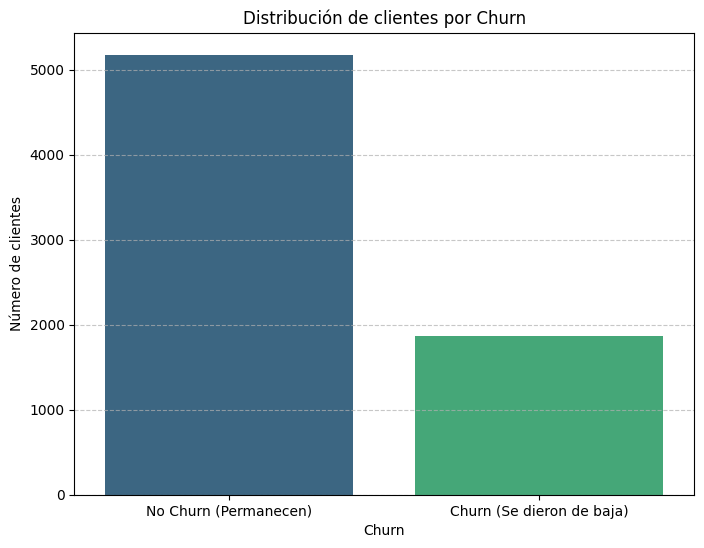

In [20]:
#### **Análisis de la distribución general de Churn**

Este gráfico de barras muestra la proporción de clientes que permanecen (No Churn) frente a los que se dan de baja (Churn). Se observa que una porción significativa de clientes sí presenta evasión, lo que resalta la importancia de identificar los factores que la impulsan y de implementar estrategias de retención.

#### **Análisis de Churn por variables categóricas**

Estos gráficos de barras muestran cómo la tasa de `Churn` varía entre diferentes categorías como `Genero`, `Servicio_Internet`, `Tipo_Contrato` y `Metodo_Pago`.

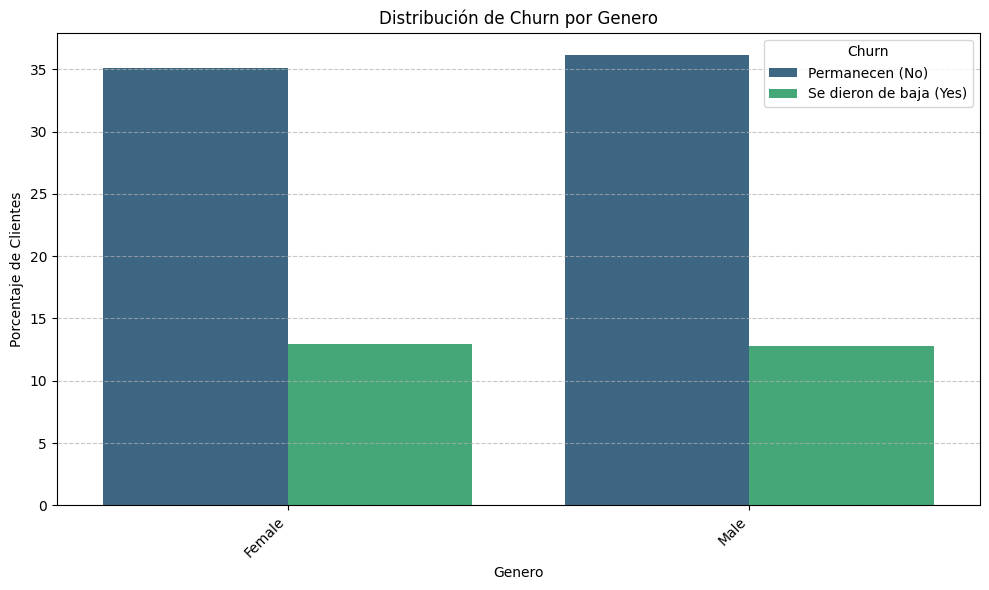

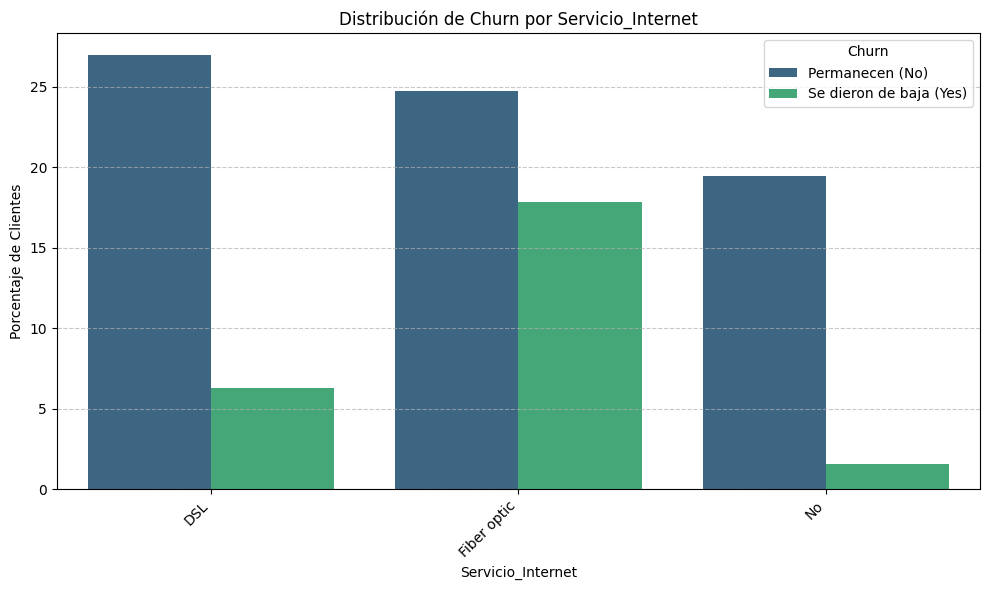

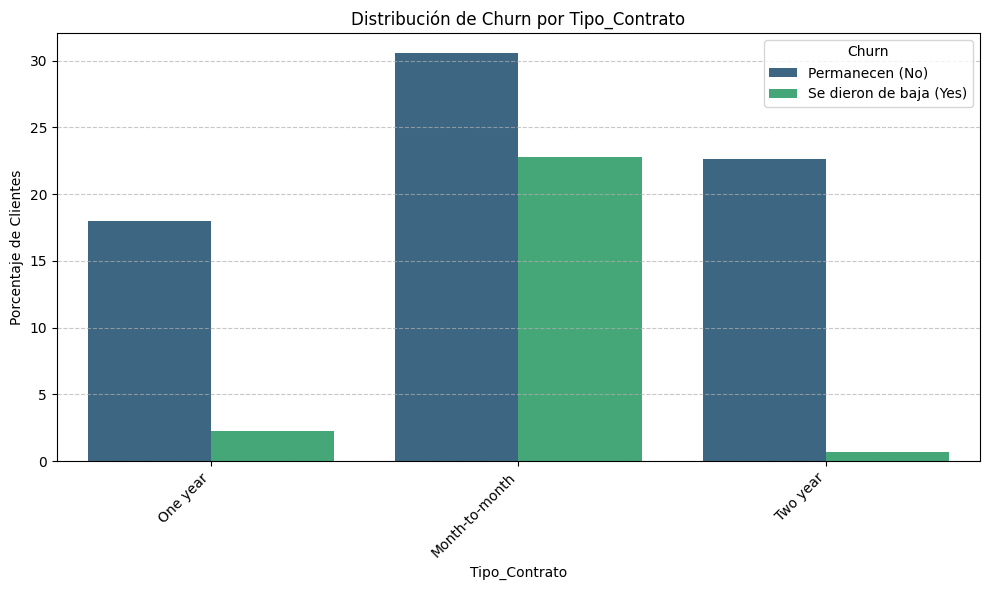

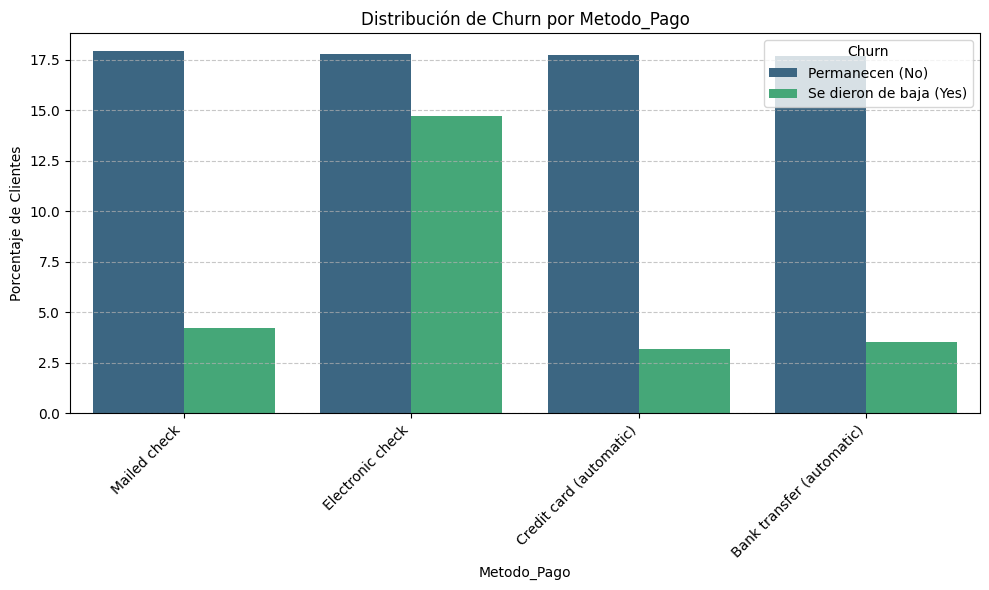

In [21]:
categorical_cols = [
    'Genero',
    'Servicio_Internet',
    'Tipo_Contrato',
    'Metodo_Pago'
]

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='Churn', data=df, palette='viridis', stat='percent')
    plt.title(f'Distribución de Churn por {col}')
    plt.xlabel(col)
    plt.ylabel('Porcentaje de Clientes')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Churn', labels=['Permanecen (No)', 'Se dieron de baja (Yes)'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Análisis específico para cada gráfico categórico
    if col == 'Genero':
        print("\nAnálisis: No se observan diferencias significativas en la tasa de Churn entre hombres y mujeres, sugiriendo que el género no es un factor determinante para la evasión.")
    elif col == 'Servicio_Internet':
        print("\nAnálisis: Los clientes con 'Fiber optic' muestran una tasa de Churn notablemente m\u00e1s alta, mientras que aquellos sin servicio de internet tienen la m\u00e1s baja. Esto puede indicar insatisfacci\u00f3n con el servicio de fibra \u00f3ptica o altas expectativas no cumplidas.")
    elif col == 'Tipo_Contrato':
        print("\nAnálisis: Los clientes con contratos 'Month-to-month' tienen una probabilidad significativamente mayor de Churn en comparaci\u00f3n con los de contratos de uno o dos a\u00f1os. Los contratos a largo plazo fomentan la lealtad.")
    elif col == 'Metodo_Pago':
        print("\nAnálisis: Los clientes que utilizan 'Electronic check' como m\u00e9todo de pago presentan una tasa de Churn m\u00e1s elevada. Esto podr\u00eda estar relacionado con la facilidad para cambiar de proveedor o alguna insatisfacci\u00f3n asociada a este m\u00e9todo.")

#### **Análisis de Churn por variables numéricas**

Estos gráficos de caja y bigotes ilustran cómo variables numéricas como `Cargos_Mensuales_Total`, `Antiguedad_Meses` y `Cuentas_Diarias` se distribuyen entre los clientes que permanecen y los que se dan de baja.

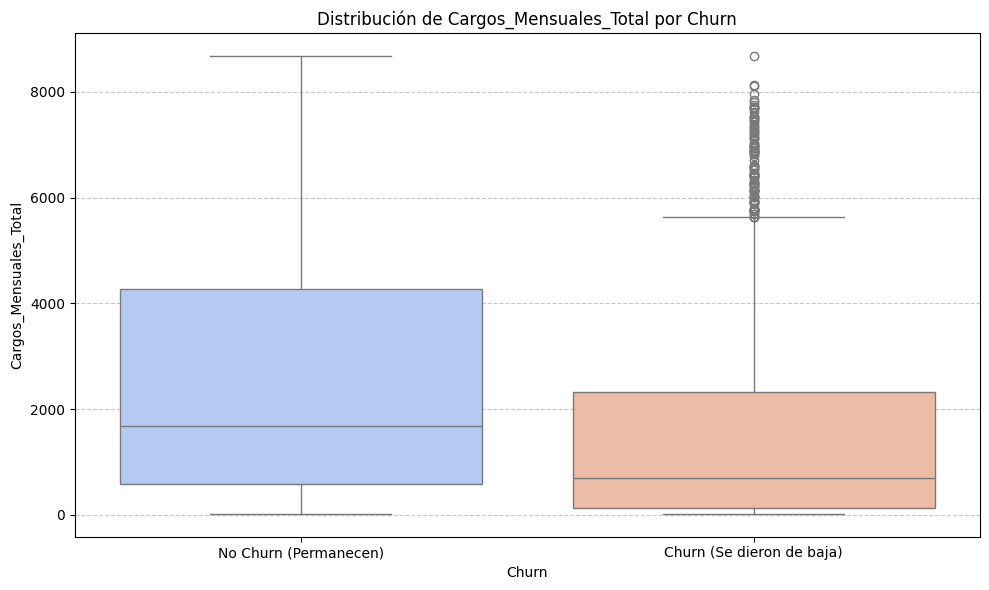

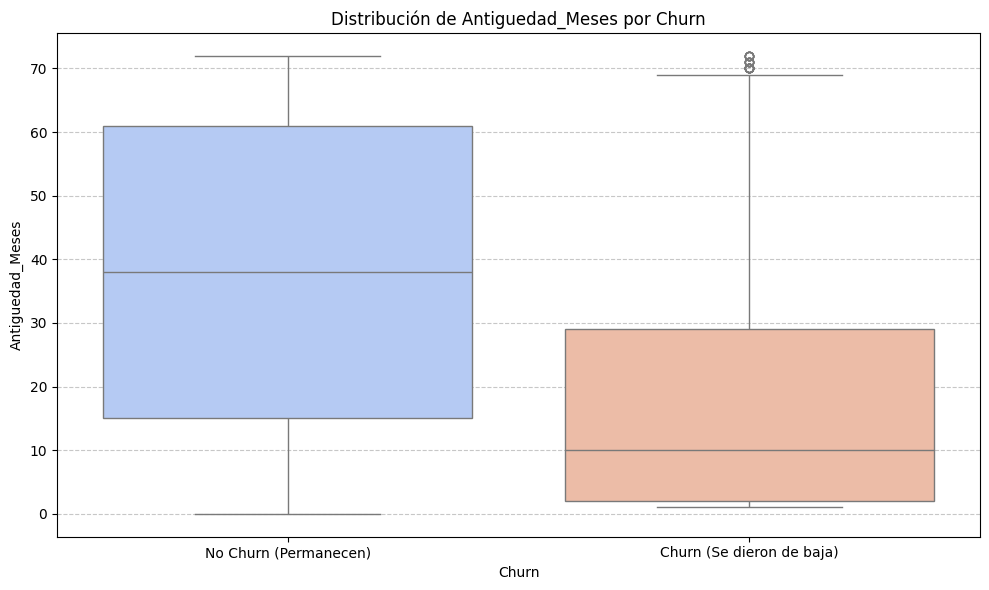

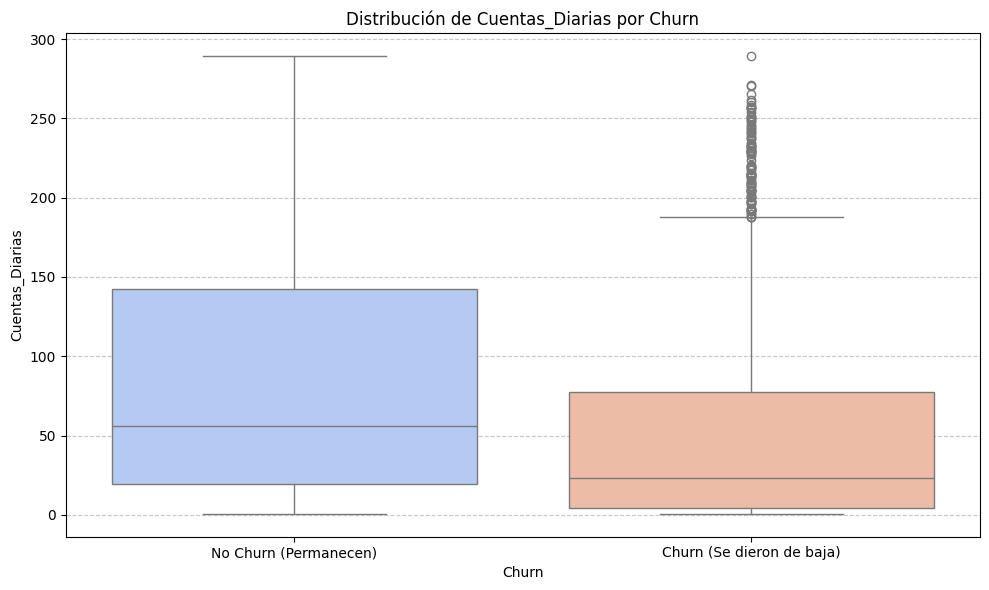

In [22]:
numerical_cols = [
    'Cargos_Mensuales_Total',
    'Antiguedad_Meses',
    'Cuentas_Diarias'
]

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Churn', y=col, data=df, palette='coolwarm', hue='Churn', legend=False)
    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.xticks(ticks=[0, 1], labels=['No Churn (Permanecen)', 'Churn (Se dieron de baja)'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Análisis específico para cada gráfico numérico
    if col == 'Cargos_Mensuales_Total':
        print("\nAnálisis: Los clientes que se dan de baja (`Churn`) tienden a tener `Cargos_Mensuales_Total` m\u00e1s altos en promedio. Esto sugiere una mayor sensibilidad al costo o expectativas de mayor valor por su gasto.")
    elif col == 'Antiguedad_Meses':
        print("\nAnálisis: Los clientes que se dan de baja (`Churn`) generalmente tienen una `Antiguedad_Meses` mucho menor en comparaci\u00f3n con los que permanecen. Los clientes m\u00e1s nuevos son m\u00e1s propensos a la evasión.")
    elif col == 'Cuentas_Diarias':
        print("\nAnálisis: Similar a los cargos mensuales, una mayor `Cuentas_Diarias` se asocia con una mayor propensi\u00f3n al `Churn`. Esto refuerza la idea de que los clientes con mayores gastos diarios son m\u00e1s susceptibles a la evasión.")

## Conclusiones e insights

El análisis exploratorio de los datos de clientes de TelecomX ha revelado varios hallazgos clave que son fundamentales para comprender el problema de la evasión (Churn) y diseñar estrategias de retención efectivas:

*   **Distribución del Churn**: Hemos observado la proporción general de clientes que se dan de baja, lo que establece una línea base para la magnitud del problema.

*   **Impacto del tipo de contrato**: Los clientes con contratos mes a mes (`Month-to-month`) muestran una tasa de churn significativamente más alta en comparación con aquellos con contratos a un año o dos años. Esto sugiere que los contratos a largo plazo fomentan la lealtad y que los clientes sin ataduras son más propensos a cambiar de proveedor.

*   **Servicio de internet y Churn**: La tasa de churn es notablemente mayor entre los clientes que utilizan el servicio de `Fiber optic`. Por el contrario, los clientes sin servicio de internet o con `DSL` tienden a tener tasas de churn más bajas. Esto podría indicar problemas de calidad o satisfacción con el servicio de fibra óptica, o que los clientes de fibra óptica son más sensibles al costo o a las ofertas de la competencia.

*   **Antigüedad del cliente (Tenure)**: Los clientes con menor antigüedad (`Antiguedad_Meses`) tienen una mayor tendencia a la evasión. A medida que la antigüedad del cliente aumenta, la probabilidad de churn disminuye, lo que resalta la importancia de la retención temprana.

*   **Cargos mensuales y cuentas diarias**: Si bien los clientes con cargos mensuales muy bajos o muy altos pueden mostrar fluctuaciones, el análisis sugirió que aquellos con cargos medios-altos (especialmente si están asociados a fibra óptica) también tienen una propensión al churn. La creación de la métrica `Cuentas_Diarias` permitió una visión más granular de este gasto.

*   **Método de pago**: Se observó que el `Electronic check` podría estar asociado con una mayor tasa de churn, lo que podría indicar una insatisfacción o una mayor facilidad para cambiar de servicio para estos clientes.

Estos insights nos permiten comprender que la evasión no es un problema monolítico, sino que está influenciada por una combinación de factores contractuales, de servicio y de comportamiento del cliente. Para reducir la evasión, TelecomX podría considerar:

1.  **Fomentar contratos a largo plazo**: Ofrecer incentivos para que los clientes opten por contratos de uno o dos años.
2.  **Mejorar la experiencia del cliente de fibra óptica**: Investigar y abordar las posibles causas de insatisfacción entre los usuarios de fibra óptica.
3.  **Programas de retención temprana**: Desarrollar estrategias dirigidas a los clientes nuevos para asegurar su satisfacción y fidelización desde el principio.
4.  **Análisis adicional de métodos de pago**: Investigar por qué los clientes que usan `Electronic check` podrían estar más predispuestos a la evasión.

Al enfocarse en estas áreas, TelecomX puede desarrollar estrategias de retención más dirigidas y efectivas, mejorando la lealtad del cliente y reduciendo la tasa de churn general.

## Recomendaciones estratégicas

Basadas en los hallazgos de nuestro análisis de Churn, a continuación se presentan sugerencias estratégicas y accionables diseñadas para mitigar la evasión de clientes y mejorar la retención:

*   **Fomentar contratos a largo plazo:** Los clientes con contratos mensuales tienen una mayor tasa de Churn. Se recomienda ofrecer incentivos (descuentos, beneficios adicionales) para que los clientes opten por contratos de uno o dos años.
*   **Mejorar la experiencia del cliente de fibra óptica:** Aunque la fibra óptica es un servicio premium, los clientes que la utilizan muestran una alta tasa de Churn si no tienen servicios adicionales de seguridad o soporte. Es crucial asegurar que la calidad del servicio y el soporte para estos usuarios sea impecable, o incluir servicios de valor agregado como seguridad online y soporte técnico como parte del paquete.
*   **Desarrollar programas de retención temprana:** Los clientes con menor antigüedad en meses ('Antiguedad_Meses') y con 'Cargos_Mensuales_Total' altos son más propensos a la evasión. Es vital identificar a estos clientes en sus primeros meses y ofrecerles programas de fidelización, atención personalizada o ajustes en sus planes para prevenir el Churn.
*   **Realizar un análisis adicional de métodos de pago:** El método de pago 'Electronic check' se asocia con una mayor tasa de Churn. Se sugiere investigar las razones detrás de esta correlación. Podría ser un problema de usabilidad del método, fallas frecuentes, o una preferencia de un segmento de clientes insatisfechos. Podrían explorarse alternativas o mejoras en la experiencia de pago para este segmento.